In [2]:
# the libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator, AutoMinorLocator





from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [3]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds


In [4]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)

In [5]:
nino34 = sst.sel(lon=slice(360-170.,360-120.), lat=slice(5,-5))
w = np.cos(np.deg2rad(nino34.lat))
nino34 = nino34.weighted(w).mean(['lat', 'lon'])
nino34 = nino34.groupby('time.month')-nino34.groupby('time.month').mean()

In [6]:
nino34 = nino34.rolling(time = 3, center = True, min_periods = 1).mean()

In [6]:
q10 = nino34.groupby('time.month').quantile(0.1).sst
q90 = nino34.groupby('time.month').quantile(0.9).sst



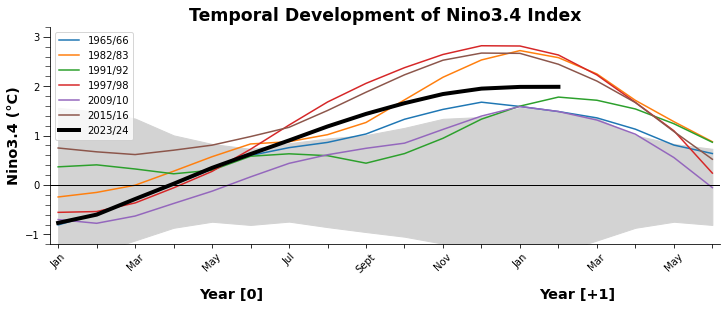

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

years = [1965, 1982, 1991, 1997, 2009, 2015, 2023]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']



# Normalize the colormap
norm = mcolors.Normalize(vmin=0, vmax=9)

for i,y in enumerate(years): 
    d = nino34.sel(time=slice(f'{y}-01', f'{y+1}-06'))
    if y == 2023:
        ax.plot(d.sst.data, label=f'{y}/{str(y+1)[-2:]}', color = 'k', linewidth = 4)
    else:
        ax.plot(d.sst.data, label=f'{y}/{str(y+1)[-2:]}')#, c = plt.cm.coolwarm(norm(d.sel(time = '{}-01'.format(y+1)).sst.data**2)))
    
q10 = nino34.groupby('time.month').quantile(0.1).sst
q90 = nino34.groupby('time.month').quantile(0.9).sst
plt.fill_between(np.arange(0,18,1), np.concatenate([q10.data, q10.data[:6]]), np.concatenate([q90.data, q90.data[:6]]), 
                color = 'lightgrey')

ax.set_xticks(np.arange(len(months)))
ax.set_xticklabels(['' if i % 2 == 1 else month for i, month in enumerate(months)], rotation=45)  # Show every second tick label
ax.axhline(0, color='k', linewidth=1)
ax.legend()

# Add custom labels for 'year 0' and 'year +1'
mid_point = len(months) // 2
ax.text(mid_point/2, -0.2, 'Year [0]', fontweight = 'bold', size = 'x-large', ha='center', va='top', transform=ax.get_xaxis_transform())
ax.text(mid_point + mid_point/2, -0.2, 'Year [+1]',  fontweight = 'bold', size = 'x-large', ha='center', va='top', transform=ax.get_xaxis_transform())

# Add minor and major ticks to the y-axis
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(0.2))
ax.tick_params(axis='y', which='both', length=5)  # Customize tick length for better visibility
ax.tick_params(axis='y', which='major', length=7)  # Make major ticks a bit longer

# Add labels for x and y axes
ax.set_xlabel(' ', fontweight='bold')
ax.set_ylabel('Nino3.4 (°C)')
ax.set_title('Temporal Development of Nino3.4 Index')


ax.set_xlim(-0.2,17.2)
ax.set_ylim(-1.2, 3.2)

# Remove the frame (top and right side)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.show()

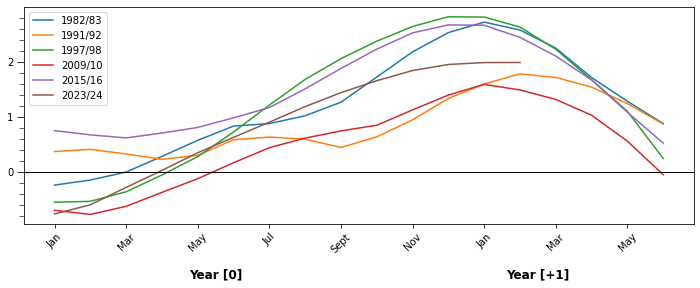

In [8]:
fig, ax = plt.subplots(1,1, figsize= (12,4))

years = [1982, 1991, 1997, 2009, 2015, 2023]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug','Sept','Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

for y in years: 
    d = nino34.sel(time = slice('{}-01'.format(y), '{}-06'.format(y+1)))
    ax.plot(d.sst.data, label = '{}/{}'.format(y, str(y+1)[-2:]))
    
season_labels = ['Winter', 'Spring', 'Summer', 'Fall', 'Winter', 'Spring']

    
ax.set_xticks(np.arange(len(months))[::2])
ax.set_xticklabels(months[::2], rotation = 45)
ax.axhline(0, color = 'k', linewidth = 1)
ax.legend()

# Add custom labels for 'year 0' and 'year +1'
mid_point = len(months) // 2
ax.text(mid_point/2, -0.2, 'Year [0]', fontweight = 'bold', size = 12, ha='center', va='top', transform=ax.get_xaxis_transform())
ax.text(mid_point + mid_point/2, -0.2, 'Year [+1]',  fontweight = 'bold', size = 12, ha='center', va='top', transform=ax.get_xaxis_transform())

# Add minor and major ticks to the y-axis
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(0.2))
ax.tick_params(axis='y', which='both', length=5)  # Customize tick length for better visibility
ax.tick_params(axis='y', which='major', length=7)  # Make major ticks a bit longer

# Add labels for x and y axes
#ax.set_xlabel('Months')

plt.show()

In [7]:
ninowest = sst.sel(lon=slice(130.,150.), lat=slice(15,0))


w = np.cos(np.deg2rad(ninowest.lat))
ninowest = ninowest.weighted(w).mean(['lat', 'lon'])
ninowest = ninowest.groupby('time.month')-ninowest.groupby('time.month').mean()

In [8]:
ninowest = ninowest.rolling(time = 3, center = True, min_periods = 1).mean()

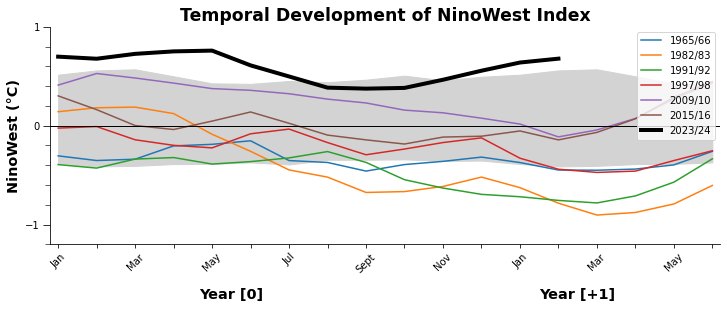

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

years = [1965, 1982, 1991, 1997, 2009, 2015, 2023]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']



# Normalize the colormap
norm = mcolors.Normalize(vmin=0, vmax=9)

for i,y in enumerate(years): 
    d = ninowest.sel(time=slice(f'{y}-01', f'{y+1}-06'))
    if y == 2023:
        ax.plot(d.sst.data, label=f'{y}/{str(y+1)[-2:]}', color = 'k', linewidth = 4)
    else:
        ax.plot(d.sst.data, label=f'{y}/{str(y+1)[-2:]}')#, c = plt.cm.coolwarm(norm(d.sel(time = '{}-01'.format(y+1)).sst.data**2)))
    
    
q10 = ninowest.groupby('time.month').quantile(0.1).sst
q90 = ninowest.groupby('time.month').quantile(0.9).sst
ax.fill_between(np.arange(0,18,1), np.concatenate([q10.data, q10.data[:6]]), np.concatenate([q90.data, q90.data[:6]]), 
                color = 'lightgrey')
    


ax.set_xticks(np.arange(len(months)))
ax.set_xticklabels(['' if i % 2 == 1 else month for i, month in enumerate(months)], rotation=45)  # Show every second tick label
ax.axhline(0, color='k', linewidth=1)
ax.legend()

# Add custom labels for 'year 0' and 'year +1'
mid_point = len(months) // 2
ax.text(mid_point/2, -0.2, 'Year [0]', fontweight = 'bold', size = 'x-large', ha='center', va='top', transform=ax.get_xaxis_transform())
ax.text(mid_point + mid_point/2, -0.2, 'Year [+1]',  fontweight = 'bold', size = 'x-large', ha='center', va='top', transform=ax.get_xaxis_transform())

# Add minor and major ticks to the y-axis
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(0.2))
ax.tick_params(axis='y', which='both', length=5)  # Customize tick length for better visibility
ax.tick_params(axis='y', which='major', length=7)  # Make major ticks a bit longer

# Add labels for x and y axes
ax.set_xlabel(' ', fontweight='bold')
ax.set_ylabel('NinoWest (°C)')
ax.set_title('Temporal Development of NinoWest Index')


ax.set_xlim(-0.2,17.2)
ax.set_ylim(-1.2, 1.)

# Remove the frame (top and right side)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.show()

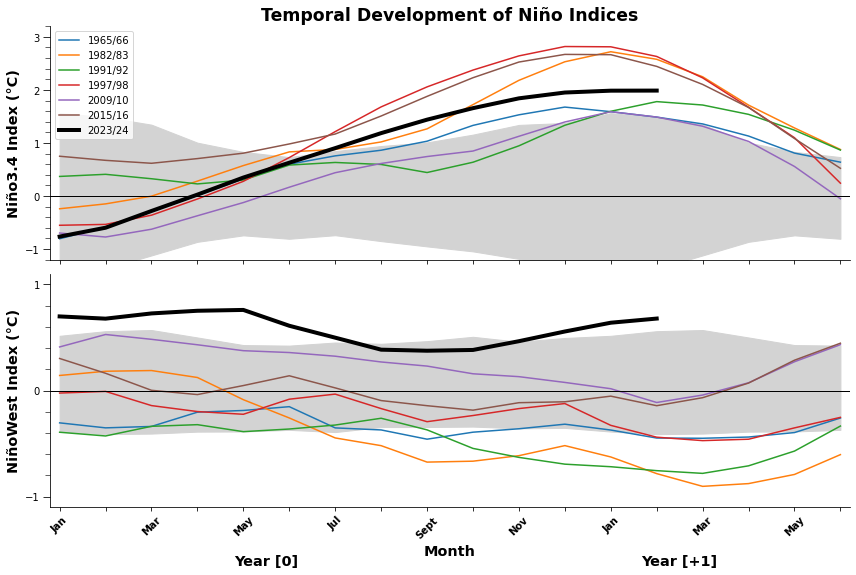

In [12]:
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.ticker import MultipleLocator
import numpy as np

# Assuming ninowest and nino34 are defined elsewhere

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)  # Creating subplots with shared x-axis

years = [1965, 1982, 1991, 1997, 2009, 2015, 2023]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

# Normalize the colormap
norm = mcolors.Normalize(vmin=0, vmax=9)

for i,y in enumerate(years): 
    d1 = nino34.sel(time=slice(f'{y}-01', f'{y+1}-06'))
    d2 = ninowest.sel(time=slice(f'{y}-01', f'{y+1}-06'))
    
    if y == 2023:
        ax1.plot(d1.sst.data, label=f'{y}/{str(y+1)[-2:]}', color='k', linewidth=4)
        ax2.plot(d2.sst.data, label=f'{y}/{str(y+1)[-2:]}', color='k', linewidth=4)
    else:
        ax1.plot(d1.sst.data, label=f'{y}/{str(y+1)[-2:]}')
        ax2.plot(d2.sst.data, label=f'{y}/{str(y+1)[-2:]}')
        
        
    
q10 = nino34.groupby('time.month').quantile(0.1).sst
q90 = nino34.groupby('time.month').quantile(0.9).sst
ax1.fill_between(np.arange(0,18,1), np.concatenate([q10.data, q10.data[:6]]), np.concatenate([q90.data, q90.data[:6]]), 
                color = 'lightgrey')

q10 = ninowest.groupby('time.month').quantile(0.1).sst
q90 = ninowest.groupby('time.month').quantile(0.9).sst
ax2.fill_between(np.arange(0,18,1), np.concatenate([q10.data, q10.data[:6]]), np.concatenate([q90.data, q90.data[:6]]), 
                color = 'lightgrey')
  

ax1.set_xticks(np.arange(len(months)))
ax1.set_xticklabels(['' if i % 2 == 1 else month for i, month in enumerate(months)], rotation=45, fontweight = 'bold')  # Show every second tick label
ax2.set_xticks(np.arange(len(months)))
ax2.set_xticklabels(['' if i % 2 == 1 else month for i, month in enumerate(months)], rotation=45, fontweight = 'bold')  # Show every second tick label

# Add custom labels for 'year 0' and 'year +1'
mid_point = len(months) // 2
ax2.text(mid_point/2, -0.2, 'Year [0]', fontweight='bold', size='x-large', ha='center', va='top', transform=ax2.get_xaxis_transform())
ax2.text(mid_point + mid_point/2, -0.2, 'Year [+1]', fontweight='bold', size='x-large', ha='center', va='top', transform=ax2.get_xaxis_transform())

# Add minor and major ticks to the y-axis
for ax in [ax1, ax2]:
    ax.axhline(0, color='k', linewidth=1)
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.2))
    ax.tick_params(axis='y', which='both', length=5)  # Customize tick length for better visibility
    ax.tick_params(axis='y', which='major', length=7)  # Make major ticks a bit longer

    
ax1.set_ylabel('Niño3.4 Index (°C)')
ax2.set_ylabel('NiñoWest Index (°C)')

# Add labels for x and y axes
ax2.set_xlabel('Month', fontweight='bold')

# Set titles
ax1.set_title('Temporal Development of Niño Indices')

# Set shared limits for x-axis
ax1.set_xlim(-0.2, 17.2)

ax1.set_ylim(-1.2,3.2)
ax2.set_ylim(-1.1,1.1)


# Remove the frame (top and right side)
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Add legend
ax1.legend()
#ax2.legend()

plt.tight_layout()
plt.show()


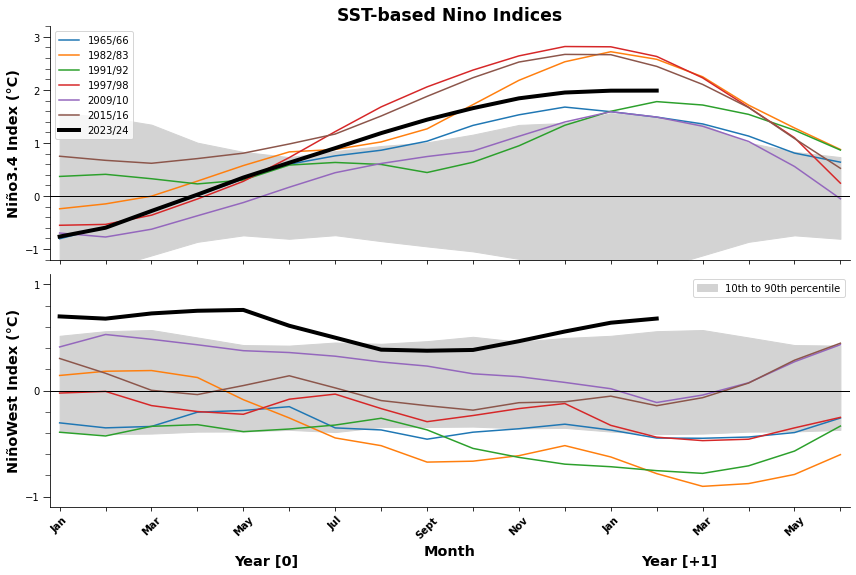

In [9]:
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.ticker import MultipleLocator
import numpy as np
from matplotlib.patches import Patch


# Assuming ninowest and nino34 are defined elsewhere

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)  # Creating subplots with shared x-axis

years = [1965, 1982, 1991, 1997, 2009, 2015, 2023]
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

# Normalize the colormap
norm = mcolors.Normalize(vmin=0, vmax=9)

for i, y in enumerate(years): 
    d1 = nino34.sel(time=slice(f'{y}-01', f'{y+1}-06'))
    d2 = ninowest.sel(time=slice(f'{y}-01', f'{y+1}-06'))
    
    if y == 2023:
        ax1.plot(d1.sst.data, label=f'{y}/{str(y+1)[-2:]}', color='k', linewidth=4)
        ax2.plot(d2.sst.data, label=f'{y}/{str(y+1)[-2:]}', color='k', linewidth=4)
    else:
        ax1.plot(d1.sst.data, label=f'{y}/{str(y+1)[-2:]}')
        ax2.plot(d2.sst.data, label=f'{y}/{str(y+1)[-2:]}')

# 10th to 90th percentile shading
q10 = nino34.groupby('time.month').quantile(0.1).sst
q90 = nino34.groupby('time.month').quantile(0.9).sst
ax1.fill_between(np.arange(0, 18, 1), np.concatenate([q10.data, q10.data[:6]]), np.concatenate([q90.data, q90.data[:6]]), 
                         color='lightgrey')

q10 = ninowest.groupby('time.month').quantile(0.1).sst
q90 = ninowest.groupby('time.month').quantile(0.9).sst
ax2.fill_between(np.arange(0, 18, 1), np.concatenate([q10.data, q10.data[:6]]), np.concatenate([q90.data, q90.data[:6]]), 
                 color='lightgrey')


"""
# 25th to 75th percentile shading
q25 = nino34.groupby('time.month').quantile(0.25).sst
q75 = nino34.groupby('time.month').quantile(0.75).sst
ax1.fill_between(np.arange(0, 18, 1), np.concatenate([q25.data, q25.data[:6]]), np.concatenate([q75.data, q75.data[:6]]), 
                         color='darkgrey')

q25 = ninowest.groupby('time.month').quantile(0.25).sst
q75 = ninowest.groupby('time.month').quantile(0.75).sst
ax2.fill_between(np.arange(0, 18, 1), np.concatenate([q25.data, q25.data[:6]]), np.concatenate([q75.data, q75.data[:6]]), 
                 color='darkgrey')
"""


ax1.set_xticks(np.arange(len(months)))
ax1.set_xticklabels(['' if i % 2 == 1 else month for i, month in enumerate(months)], rotation=45, fontweight='bold')  # Show every second tick label
ax2.set_xticks(np.arange(len(months)))
ax2.set_xticklabels(['' if i % 2 == 1 else month for i, month in enumerate(months)], rotation=45, fontweight='bold')  # Show every second tick label

# Add custom labels for 'year 0' and 'year +1'
mid_point = len(months) // 2
ax2.text(mid_point / 2, -0.2, 'Year [0]', fontweight='bold', size='x-large', ha='center', va='top', transform=ax2.get_xaxis_transform())
ax2.text(mid_point + mid_point / 2, -0.2, 'Year [+1]', fontweight='bold', size='x-large', ha='center', va='top', transform=ax2.get_xaxis_transform())

# Add minor and major ticks to the y-axis
for ax in [ax1, ax2]:
    ax.axhline(0, color='k', linewidth=1)
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.2))
    ax.tick_params(axis='y', which='both', length=5)  # Customize tick length for better visibility
    ax.tick_params(axis='y', which='major', length=7)  # Make major ticks a bit longer

ax1.set_ylabel('Niño3.4 Index (°C)')
ax2.set_ylabel('NiñoWest Index (°C)')

# Add labels for x and y axes
ax2.set_xlabel('Month', fontweight='bold')

# Set titles
ax1.set_title('SST-based Nino Indices')

# Set shared limits for x-axis
ax1.set_xlim(-0.2, 17.2)
ax1.set_ylim(-1.2, 3.2)
ax2.set_ylim(-1.1, 1.1)

# Remove the frame (top and right side)
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Add legends
ax1.legend(loc='upper left')

# Create custom legend patches
q10_patch = Patch(color='lightgrey', label='10th to 90th percentile')
q90_patch = Patch(color='darkgrey', label='25th to 75th percentile')

# Add the custom legend to the plot
ax2.legend(handles=[q10_patch])






plt.tight_layout()
plt.show()


In [7]:
nino34

<xarray.Dataset>
Dimensions:  (time: 889)
Coordinates:
  * time     (time) datetime64[ns] 1950-02-01 1950-03-01 ... 2024-02-01
    month    (time) int64 2 3 4 5 6 7 8 9 10 11 12 ... 4 5 6 7 8 9 10 11 12 1 2
Data variables:
    sst      (time) float64 -0.8733 -0.8131 -0.8054 ... 1.951 1.985 1.987